Prueba con el G1

In [3]:
import mujoco
import mediapy as media

Añado el robot utilizando la ruta al xml

""

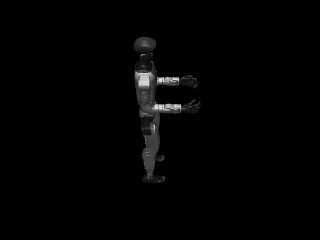

In [4]:
model = mujoco.MjModel.from_xml_path("../../../../mjlab/src/mjlab/asset_zoo/robots/unitree_g1/xmls/g1.xml")
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [5]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


Cuando lo simulo no tiene suelo por lo que se cae

Muevo el modelo a la carpeta para poder importarlo y añadir suelo

""

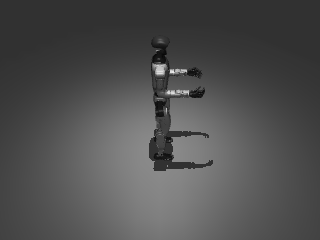

In [6]:
xml = """
<mujoco>
  <include file="g1.xml"/>
  <worldbody>
    <geom name="plane" type="plane" size="5 5 0.1"/>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [7]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [8]:
for i in range(model.nu):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
    print(i, name)

El modelo no tiene las articulaciones configuradas por lo que no detecta ninguna

Importo el modelo desde g1_constants.py para que tenga articulaciones

""

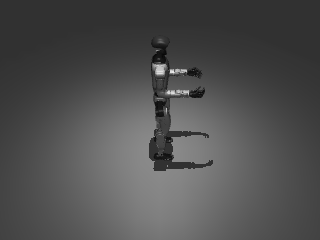

In [9]:
import mujoco
from mjlab.entity.entity import Entity
from g1_constants import get_g1_robot_cfg

robot = Entity(get_g1_robot_cfg())

spec = robot.spec

world = spec.worldbody
world.add_geom(
    name="floor",
    type=mujoco.mjtGeom.mjGEOM_PLANE,
    size=[5, 5, 0.1],
    pos=[0, 0, 0],
)

model = spec.compile()
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)

    media.show_image(renderer.render())

In [10]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [11]:
for i in range(model.nu):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
    print(i, name)

0 left_shoulder_pitch_joint
1 left_shoulder_roll_joint
2 left_shoulder_yaw_joint
3 left_elbow_joint
4 left_wrist_roll_joint
5 right_shoulder_pitch_joint
6 right_shoulder_roll_joint
7 right_shoulder_yaw_joint
8 right_elbow_joint
9 right_wrist_roll_joint
10 left_hip_pitch_joint
11 left_hip_yaw_joint
12 right_hip_pitch_joint
13 right_hip_yaw_joint
14 waist_yaw_joint
15 left_hip_roll_joint
16 left_knee_joint
17 right_hip_roll_joint
18 right_knee_joint
19 left_wrist_pitch_joint
20 left_wrist_yaw_joint
21 right_wrist_pitch_joint
22 right_wrist_yaw_joint
23 waist_roll_joint
24 waist_pitch_joint
25 left_ankle_pitch_joint
26 left_ankle_roll_joint
27 right_ankle_pitch_joint
28 right_ankle_roll_joint


In [14]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    data.ctrl[14] = 0.8
    data.ctrl[5] = 2
    data.ctrl[3] = 0.8
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.
